In [14]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, plot_tree
from sklearn.neighbors import KNeighborsClassifier

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import accuracy_score, roc_auc_score

data = load_breast_cancer(as_frame = True)

print(data["DESCR"])
x = data["data"]
y = data["target"]

.. _breast_cancer_dataset:

Breast cancer Wisconsin (diagnostic) dataset
--------------------------------------------

**Data Set Characteristics:**

:Number of Instances: 569

:Number of Attributes: 30 numeric, predictive attributes and the class

:Attribute Information:
    - radius (mean of distances from center to points on the perimeter)
    - texture (standard deviation of gray-scale values)
    - perimeter
    - area
    - smoothness (local variation in radius lengths)
    - compactness (perimeter^2 / area - 1.0)
    - concavity (severity of concave portions of the contour)
    - concave points (number of concave portions of the contour)
    - symmetry
    - fractal dimension ("coastline approximation" - 1)

    The mean, standard error, and "worst" or largest (mean of the three
    worst/largest values) of these features were computed for each image,
    resulting in 30 features.  For instance, field 0 is Mean Radius, field
    10 is Radius SE, field 20 is Worst Radius.

    - 

In [2]:
pd.Series(y).value_counts()

1    357
0    212
Name: count, dtype: int64

In [4]:
x_train, x_test, y_train, y_test = train_test_split(x, y, random_state=42, test_size=0.3, stratify = y)
x_train, x_val, y_train, y_val = train_test_split(x_train, y_train, random_state=42, test_size=0.2, stratify = y_train)
print("Train samples: ", len(x_train))
print("Validation samples: ", len(x_val))
print("Test samples: ", len(x_test))

Train samples:  318
Validation samples:  80
Test samples:  171


# DecisionTreeClassifier

In [9]:
# TODO: Instantiate DecisionTreeClassifier (first - try without any limits!)
# Treebased methods actually don't need a scaler, as they are indifferent to feature scales! (due to them only partitioning the space)
pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("dtree", DecisionTreeClassifier(max_depth = 3)),


])

pipe.fit(x_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('dtree', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",3
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2


In [10]:
y_pred = pipe.predict(x_val)

In [11]:
accuracy_score(y_val, y_pred)

0.9625

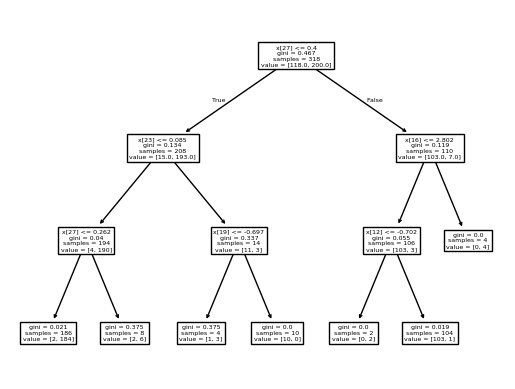

<Figure size 4000x4000 with 0 Axes>

In [12]:
# TODO: plot the resulting decision tree (plot_tree)
model = pipe["dtree"]
plot_tree(model)
plt.figure(figsize = (40,40))
plt.show()


In [16]:
x_train

array([[1.305e+01, 1.859e+01, 8.509e+01, ..., 1.258e-01, 3.113e-01,
        8.317e-02],
       [1.272e+01, 1.767e+01, 8.098e+01, ..., 3.612e-02, 2.165e-01,
        6.025e-02],
       [1.301e+01, 2.222e+01, 8.201e+01, ..., 9.259e-03, 2.295e-01,
        5.843e-02],
       ...,
       [1.283e+01, 2.233e+01, 8.526e+01, ..., 1.977e-01, 3.407e-01,
        1.243e-01],
       [1.136e+01, 1.757e+01, 7.249e+01, ..., 8.698e-02, 2.973e-01,
        7.745e-02],
       [1.471e+01, 2.159e+01, 9.555e+01, ..., 1.834e-01, 3.698e-01,
        1.094e-01]], shape=(318, 30))

[0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.02789638 0.         0.         0.         0.05274952 0.
 0.         0.02329363 0.         0.         0.         0.11078492
 0.         0.         0.         0.78527555 0.         0.        ]


<BarContainer object of 30 artists>

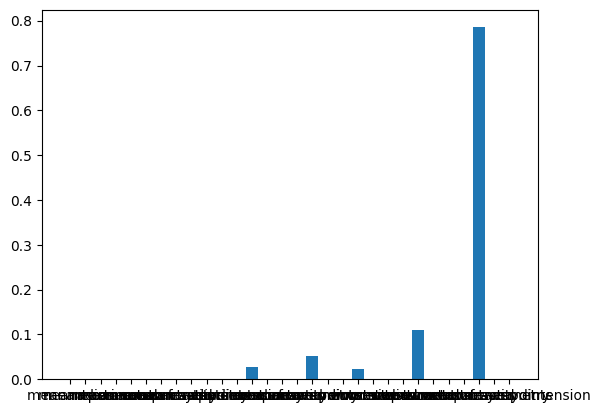

In [18]:
# TODO: Showcase how important different features were using feature_importances_
print(model.feature_importances_)
plt.bar(data["feature_names"], model.feature_importances_)


## Repetition: Validation vs. Crossvalidation

We have our separate partition for validation: x_val and y_val.


Lets now assume we use multiple model classes as so (e.g., kNN and decision tree):

In [19]:
# First we train both using gridsearch and cross validation (= only training partition)
pipe_knn = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier())
])

param_grid_knn = {
    "knn__n_neighbors": [1,3,5,7,9]
}

gcv_knn = GridSearchCV(pipe_knn, param_grid_knn, cv=3, scoring="roc_auc", n_jobs=-1)
gcv_knn.fit(x_train, y_train)

best_knn = gcv_knn.best_estimator_
gcv_knn.best_score_

np.float64(0.9865613656658433)

In [20]:
pipe_dt = Pipeline([
    ("scaler", StandardScaler()),
    ("dt", DecisionTreeClassifier())
])

param_grid_dt = {
    "dt__max_depth": [1,2,3,4,5]
}

gcv_dt = GridSearchCV(pipe_dt, param_grid_dt, cv=3, scoring="roc_auc", n_jobs=-1)
gcv_dt.fit(x_train, y_train)

best_dt = gcv_dt.best_estimator_
gcv_dt.best_score_

np.float64(0.9468009602337961)

GCV by default retrains the model using the best parameters on ALL training data at the end. --> We have exhausted this part of the data, and need new "unseen data" to estimate generalization performance without introducing optimization bias. (we used the data to tune the hyperparameters first, and then to train it).

So we evaluate both on the validation dataset:

In [22]:
gcv_knn.predict_proba(x_val)[:1]

array([[0.11111111, 0.88888889]])

In [23]:
roc_auc_score(y_val, gcv_knn.predict_proba(x_val)[:,1])

0.9933333333333334

In [24]:
roc_auc_score(y_val, gcv_dt.predict_proba(x_val)[:,1])

0.9666666666666668

Based on this performance, we pick the better model, which in this case was the kNN Model (this could obviously change with a bigger hyperparameter search space)

Only after choosing the best model, we evaluate on the test set, effectively avoiding model selection bias:

In [25]:
roc_auc_score(y_test, gcv_knn.predict_proba(x_test)[:,1])

0.9940858644859814

# DecisionTreeRegressor

In [26]:
from sklearn.datasets import fetch_california_housing
from sklearn.metrics import mean_squared_error

In [27]:
data = fetch_california_housing()
x_reg = data["data"]
y_reg = data["target"]

In [28]:
x_reg_train, x_reg_test, y_reg_train, y_reg_test = train_test_split(x_reg, y_reg, test_size=0.3, random_state=42)

In [33]:
pipe_dt_reg = Pipeline([
    ("scaler", StandardScaler()),
    ("dt_reg", DecisionTreeRegressor(max_depth=10))
])

pipe_dt_reg.fit(x_reg_train, y_reg_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('dt_reg', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the

[Text(0.5499817767118134, 0.9545454545454546, 'x[0] <= 0.606\nsquared_error = 1.34\nsamples = 14448\nvalue = 2.069'),
 Text(0.278786916854778, 0.8636363636363636, 'x[0] <= -0.421\nsquared_error = 0.835\nsamples = 11340\nvalue = 1.73'),
 Text(0.4143843467832957, 0.9090909090909092, 'True  '),
 Text(0.13047874341610233, 0.7727272727272727, 'x[2] <= -0.504\nsquared_error = 0.565\nsamples = 5490\nvalue = 1.356'),
 Text(0.06447516930022573, 0.6818181818181818, 'x[5] <= -0.055\nsquared_error = 0.701\nsamples = 2018\nvalue = 1.664'),
 Text(0.03531790820165538, 0.5909090909090909, 'x[6] <= 1.067\nsquared_error = 1.065\nsamples = 594\nvalue = 2.096'),
 Text(0.019845748683220466, 0.5, 'x[7] <= 0.659\nsquared_error = 1.071\nsamples = 505\nvalue = 2.237'),
 Text(0.0099699021820918, 0.4090909090909091, 'x[7] <= -1.373\nsquared_error = 1.171\nsamples = 303\nvalue = 2.582'),
 Text(0.004890895410082769, 0.3181818181818182, 'x[3] <= 0.189\nsquared_error = 1.315\nsamples = 39\nvalue = 3.416'),
 Text(0.0

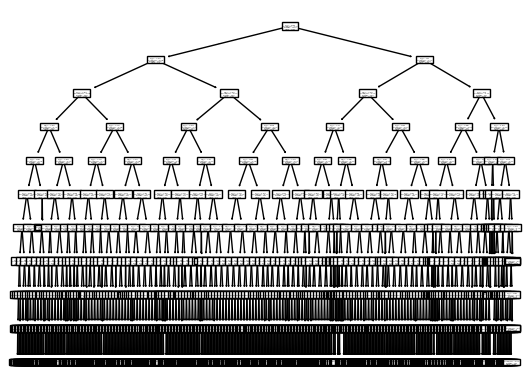

In [34]:
plot_tree(pipe_dt_reg["dt_reg"])

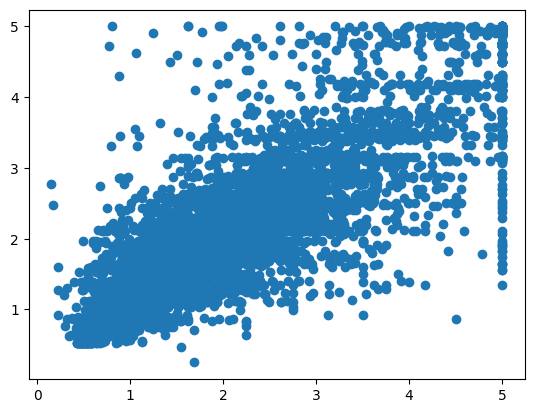

In [35]:
plt.scatter(y_reg_test, pipe_dt_reg.predict(x_reg_test))

In [32]:
mean_squared_error(y_reg_test, pipe_dt_reg.predict(x_reg_test))

0.7359660480724025